# Cleaning & Analyzing Real Airbnb Data (NYC, 2019)

**Dataset:** [New York City Airbnb Open Data (Kaggle)](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data) 
— 48,895 real listings scraped from Airbnb

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('AB_NYC_2019.csv')
print(df.shape)
df.head()


(48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
audit = pd.DataFrame({
    'missing': df.isna().sum(),
    'pct_missing': (df.isna().sum() / len(df) * 100).round(2)
})
audit

,missing,pct_missing
id,0,0.00
name,16,0.03
host_id,0,0.00
host_name,21,0.04
neighbourhood_group,0,0.00
neighbourhood,0,0.00
latitude,0,0.00
longitude,0,0.00
room_type,0,0.00
price,0,0.00


In [4]:
never_reviewed = df[df['last_review'].isna()]
print(f"Rows missing last_review: {len(never_reviewed)}")
print(f"Of those, number_of_reviews == 0: {(never_reviewed['number_of_reviews']==0).sum()}")

Rows missing last_review: 10052
Of those, number_of_reviews == 0: 10052


In [5]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
# last_review intentionally left as-is (genuinely no review ever occurred)
df['name'] = df['name'].fillna('Unnamed listing')
df['host_name'] = df['host_name'].fillna('Unknown host')

In [6]:
print("Listings priced at $0:", (df['price']==0).sum())
print(df[df['price']==0][['name','room_type','neighbourhood_group','minimum_nights']])

Listings priced at $0: 11
                                                    name        room_type  \
23161  Huge Brooklyn Brownstone Living, Close to it all.     Private room   
25433      ★Hostel Style Room | Ideal Traveling Buddies★     Private room   
25634    MARTIAL LOFT 3: REDEMPTION (upstairs, 2nd room)     Private room   
25753                    Sunny, Quiet Room in Greenpoint     Private room   
25778      Modern apartment in the heart of Williamsburg  Entire home/apt   
25794  Spacious comfortable master bedroom with nice ...     Private room   
25795  Contemporary bedroom in brownstone with nice view     Private room   
25796       Cozy yet spacious private brownstone bedroom     Private room   
26259                              the best you can find  Entire home/apt   
26841  Coliving in Brooklyn! Modern design / Shared room      Shared room   
26866             Best Coliving space ever! Shared room.      Shared room   

      neighbourhood_group  minimum_nights  
23161

In [7]:
print(df['minimum_nights'].describe())
print()
print("Listings with minimum_nights > 365:", (df['minimum_nights']>365).sum())
df['price_valid'] = df['price'] > 0
df['minimum_nights_flag'] = df['minimum_nights'] > 365

print(f"Valid price rows: {df['price_valid'].sum()} / {len(df)}")
print(f"Flagged (implausible) minimum_nights rows: {df['minimum_nights_flag'].sum()}")

count    48895.000000
mean         7.029962
std         20.510550
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64

Listings with minimum_nights > 365: 14
Valid price rows: 48884 / 48895
Flagged (implausible) minimum_nights rows: 14


In [8]:
df.to_csv('airbnb_nyc_clean.csv', index=False)
print("Saved cleaned file:", df.shape)

Saved cleaned file: (48895, 18)


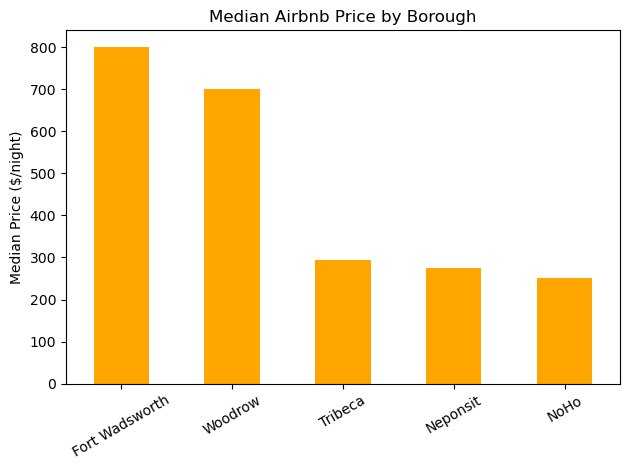

In [36]:
borough_median_price = df.groupby('neighbourhood')['price'].agg(['mean','median', 'count']).sort_values('median', ascending=False).round(2).head()
borough_median_price.head(5)

fig, ax = plt.subplots()
borough_median_price['median'].plot(kind = 'bar', ax = ax, color = 'orange')
ax.set_title('Median Airbnb Price by Borough')
ax.set_ylabel('Median Price ($/night)')
ax.set_xlabel('')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('price_by_borough.png', dpi=120)
plt.show()

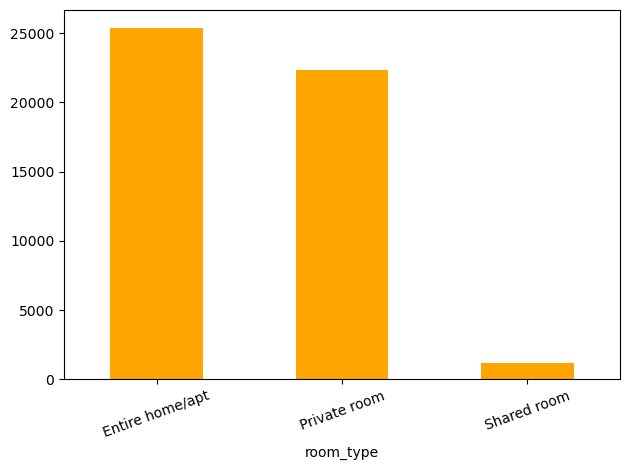

In [51]:
room_count = df['room_type'].value_counts()
room_count
room_price_avg= df.groupby('room_type')['price'].mean().round(2)
room_price_avg

room_summary = pd.DataFrame(
    {
        'count' : room_count,
        'average price' : room_price_avg
    }
)
room_summary

room_count.plot(kind = 'bar', color = 'orange')
ax.set_title('Listings by Room Type')
ax.set_ylabel('Number of Listings')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('room_type_mix.png', dpi=120)
plt.show()

In [48]:
busiest_hosts = df.groupby(['host_id','host_name'])['calculated_host_listings_count'].max().sort_values(ascending=False).head(10)
busiest_hosts

host_id    host_name        
219517861  Sonder (NYC)         327
107434423  Blueground           232
30283594   Kara                 121
137358866  Kazuya               103
16098958   Jeremy & Laura        96
12243051   Sonder                96
61391963   Corporate Housing     91
22541573   Ken                   87
200380610  Pranjal               65
1475015    Mike                  52
Name: calculated_host_listings_count, dtype: int64